In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnn.csv')
    X = X.iloc[20:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()
print(len(X))

2870


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


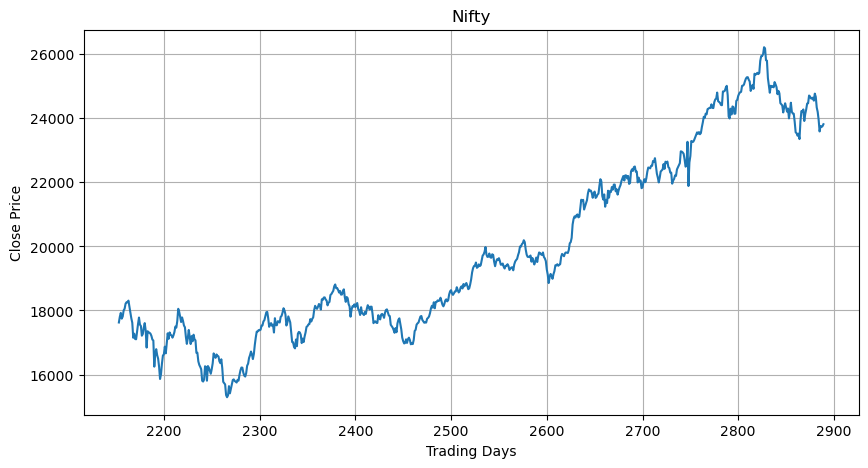

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2153:2889,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
len(X)

2870

In [7]:
X['state2d'].value_counts()

state2d
5.0    896
3.0    772
2.0    428
0.0    366
4.0    285
1.0    123
Name: count, dtype: int64

In [8]:
X.head()

,Unnamed: 0,date,Close,High,Low,Open,Volume,weekday,month,p_co,...,BBP_20_2.0,ATRr_14,Target,cnnstate,state2d,cashopen,cash,action,diff,quantity
20,20,2013-04-18,5783.100098,5794.350098,5681.850098,5682.700195,149900.0,0.75,4,0.116719,...,0.823073,0.044696,0,0.0,3.0,0.0,0.0,,,
21,21,2013-04-22,5834.399902,5844.850098,5789.799805,5789.850098,135100.0,0.00,4,0.149119,...,0.860490,0.041362,1,1.0,4.0,0.0,0.0,,,
22,22,2013-04-23,5836.899902,5844.299805,5791.549805,5843.100098,132200.0,0.25,4,0.328945,...,0.817709,0.036904,0,0.0,3.0,0.0,0.0,,,
23,23,2013-04-25,5916.299805,5924.600098,5853.299805,5856.100098,199600.0,0.75,4,-0.279732,...,0.862009,0.038064,2,2.0,2.0,0.0,0.0,,,
24,24,2013-04-26,5871.450195,5907.049805,5860.500000,5899.750000,141300.0,1.00,4,0.104742,...,0.772120,0.034307,0,0.0,3.0,0.0,0.0,,,


In [9]:
def getState(t):    
    t = int(t)
    return(X['state2d'][t])  

In [10]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        state = int(state)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [11]:
episode_count=1
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2153
    data_length=2889
    state = getState(data_length_start)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t+1)
        #print("Next state:", next_state)  # Debugging
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.00998645168764533
Episod 1/50

***********************

Profit is  60927.1483300002
Initial Capital is  173871.50389999998
Current Capital is  234798.65223000018
%ROI is  35.04148003748889
% Buy and Hold= 36.59627188627544
count 736
qtable [[0.00578653 0.00799583 0.00924003]
 [0.00450093 0.0058284  0.00919825]
 [0.00558602 0.00744974 0.00815943]
 [0.00566454 0.00768366 0.00720522]
 [0.00552883 0.00882345 0.00699758]
 [0.00580025 0.00757446 0.00646343]]
epsilon 0.00998645168764533
--------------------------------
Episod 2/50

***********************

Profit is  86924.69581999895
Initial Capital is  173871.50389999998
Current Capital is  260796.19971999893
%ROI is  49.99364120643518
% Buy and Hold= 36.59627188627544
count 736
qtable [[0.00578653 0.00799583 0.00892328]
 [0.00450093 0.0058284  0.00902638]
 [0.00558602 0.00682139 0.00745727]
 [0.00566454 0.00753328 0.00688091]
 [0.00552883 0.00861464 0.00699758]
 [0.00580025 0.00725772 0.00593902]]
epsilon 0.00998645168764533
------------

In [12]:
agent.Q

array([[0.00578653, 0.00799583, 0.00883128],
       [0.00450093, 0.0058284 , 0.00864142],
       [0.00558602, 0.00645645, 0.00757749],
       [0.00566454, 0.00744712, 0.0065375 ],
       [0.00552883, 0.00818857, 0.00699758],
       [0.00566887, 0.00717471, 0.00559708]])

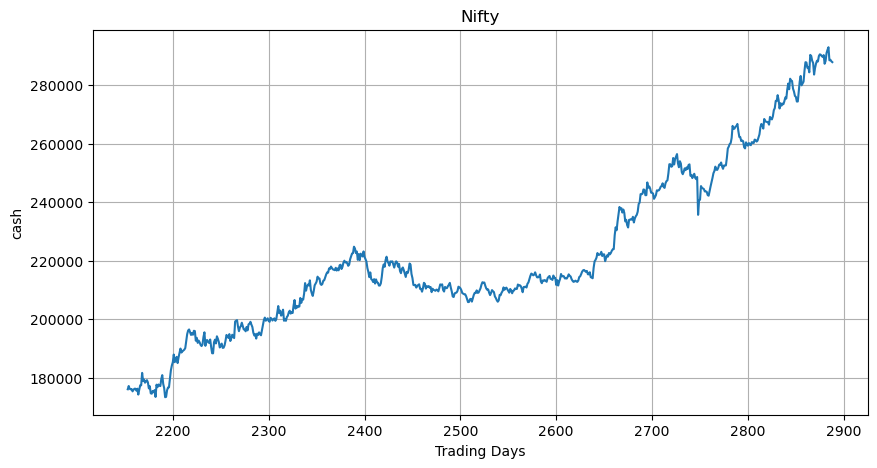

In [13]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')